In [1]:
#STEP 1: Imports and Setup
%load_ext autoreload
%autoreload 2

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import your custom modules
from ml_common import load_clean_data, DEFAULT_DATASET
from baseline_models import run_logistic_regression, run_linear_regression, build_feature_table
import random_forest_model
import svm_model
import xgboost_model
import high_performance_genre_pipeline as hp_pipeline

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

Dataset loaded: spotify_remapped.csv
Total tracks: 114000


C:\Users\kkany\AppData\Local\Temp\ipykernel_12116\668952793.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, y="track_genre", order=data["track_genre"].value_counts().index, palette="viridis")


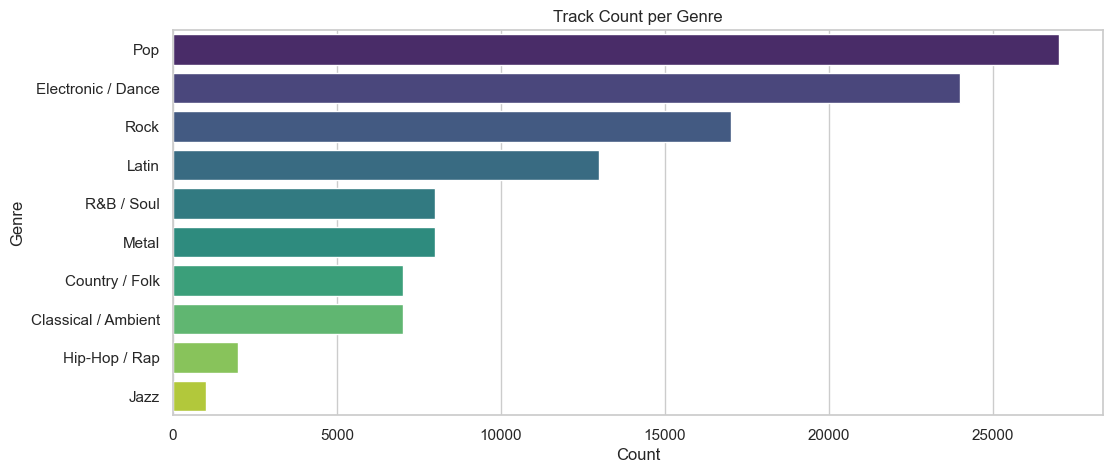

In [2]:
# STEP 2: Load and Verify Data
dataset_path = "spotify_remapped.csv" # Or spotify_balanced.csv
data = load_clean_data(dataset_path)

print(f"Dataset loaded: {dataset_path}")
print(f"Total tracks: {len(data)}")

# Visualize the class balance
plt.figure(figsize=(12, 5))
sns.countplot(data=data, y="track_genre", order=data["track_genre"].value_counts().index, palette="viridis")
plt.title("Track Count per Genre")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()

In [3]:
# STEP 3: Run Baseline Models
print("--- Running Baseline Models ---")
# Build the specific feature table expected by your baseline script
df_features = build_feature_table(pd.read_csv(dataset_path))

run_logistic_regression(df_features, test_size=0.2, random_state=42)
run_linear_regression(df_features, test_size=0.2, random_state=42)

--- Running Baseline Models ---

=== Logistic Regression (Genre Classification) ===
Train samples: 91200 | Test samples: 22800
Accuracy: 0.4027

Classification report:
                     precision    recall  f1-score   support

Classical / Ambient     0.5629    0.5336    0.5479      1400
     Country / Folk     0.3051    0.0850    0.1330      1400
 Electronic / Dance     0.4742    0.6271    0.5401      4800
      Hip-Hop / Rap     0.2653    0.0325    0.0579       400
               Jazz     0.0000    0.0000    0.0000       200
              Latin     0.3709    0.3654    0.3681      2600
              Metal     0.5336    0.5356    0.5346      1600
                Pop     0.3330    0.4431    0.3802      5400
         R&B / Soul     0.1667    0.0013    0.0025      1600
               Rock     0.3283    0.3206    0.3244      3400

           accuracy                         0.4027     22800
          macro avg     0.3340    0.2944    0.2889     22800
       weighted avg     0.3771    0.4

In [4]:
# STEP 4: Run Random Forest and SVM
# Note: You may want to use spotify_balanced.csv for SVM if the full dataset takes too long to train
print("--- Running Random Forest ---")
# You can call the main() functions directly by overriding the sys.argv if needed, 
# but for simplicity, you can also just run the scripts via shell commands in Jupyter:
!python random_forest_model.py --data spotify_remapped.csv

print("\n--- Running SVM-RBF ---")
!python svm_model.py --data spotify_balanced.csv

--- Running Random Forest ---
=== Random Forest (Genre Classification) ===
Train: 91200 | Test: 22800
Accuracy: 0.5661
                     precision    recall  f1-score   support

Classical / Ambient     0.6432    0.6850    0.6634      1400
     Country / Folk     0.6320    0.4993    0.5579      1400
 Electronic / Dance     0.6611    0.7108    0.6851      4800
      Hip-Hop / Rap     0.4220    0.1825    0.2548       400
               Jazz     0.5395    0.4100    0.4659       200
              Latin     0.6075    0.6358    0.6213      2600
              Metal     0.6256    0.5994    0.6122      1600
                Pop     0.4958    0.6043    0.5447      5400
         R&B / Soul     0.3594    0.1750    0.2354      1600
               Rock     0.4918    0.4488    0.4693      3400

           accuracy                         0.5661     22800
          macro avg     0.5478    0.4951    0.5110     22800
       weighted avg     0.5588    0.5661    0.5571     22800

=== Random Forest (Popul

In [5]:
# STEP 5: Run XGBoost (Classification & Regression)
print("--- Running XGBoost ---")
!python xgboost_model.py --data spotify_remapped.csv

--- Running XGBoost ---
=== XGBoost (Genre Classification) ===
Train: 91200 | Test: 22800
Accuracy: 0.4897
                     precision    recall  f1-score   support

Classical / Ambient     0.5457    0.7586    0.6348      1400
     Country / Folk     0.3437    0.6950    0.4599      1400
 Electronic / Dance     0.6965    0.6077    0.6491      4800
      Hip-Hop / Rap     0.1648    0.5975    0.2584       400
               Jazz     0.3103    0.6050    0.4102       200
              Latin     0.5365    0.5712    0.5533      2600
              Metal     0.5084    0.7338    0.6007      1600
                Pop     0.5988    0.2846    0.3858      5400
         R&B / Soul     0.2790    0.2869    0.2829      1600
               Rock     0.4427    0.3524    0.3924      3400

           accuracy                         0.4897     22800
          macro avg     0.4426    0.5493    0.4627     22800
       weighted avg     0.5311    0.4897    0.4870     22800



=== XGBoost (Popularity Regression

Train: 91200 | Test: 22800 | Classes: 10

=== XGBoost Genre Classifier ===
Top-1 Accuracy: 0.5122
Top-3 Accuracy: 0.8357

Classification report:
                     precision    recall  f1-score   support

Classical / Ambient     0.5602    0.7507    0.6416      1400
     Country / Folk     0.3746    0.6893    0.4854      1400
 Electronic / Dance     0.6879    0.6433    0.6649      4800
      Hip-Hop / Rap     0.1962    0.4850    0.2793       400
               Jazz     0.4317    0.5850    0.4968       200
              Latin     0.5418    0.5931    0.5663      2600
              Metal     0.5293    0.7175    0.6092      1600
                Pop     0.5917    0.3315    0.4249      5400
         R&B / Soul     0.2824    0.2888    0.2855      1600
               Rock     0.4523    0.3888    0.4182      3400

           accuracy                         0.5122     22800
          macro avg     0.4648    0.5473    0.4872     22800
       weighted avg     0.5358    0.5122    0.5088     22800

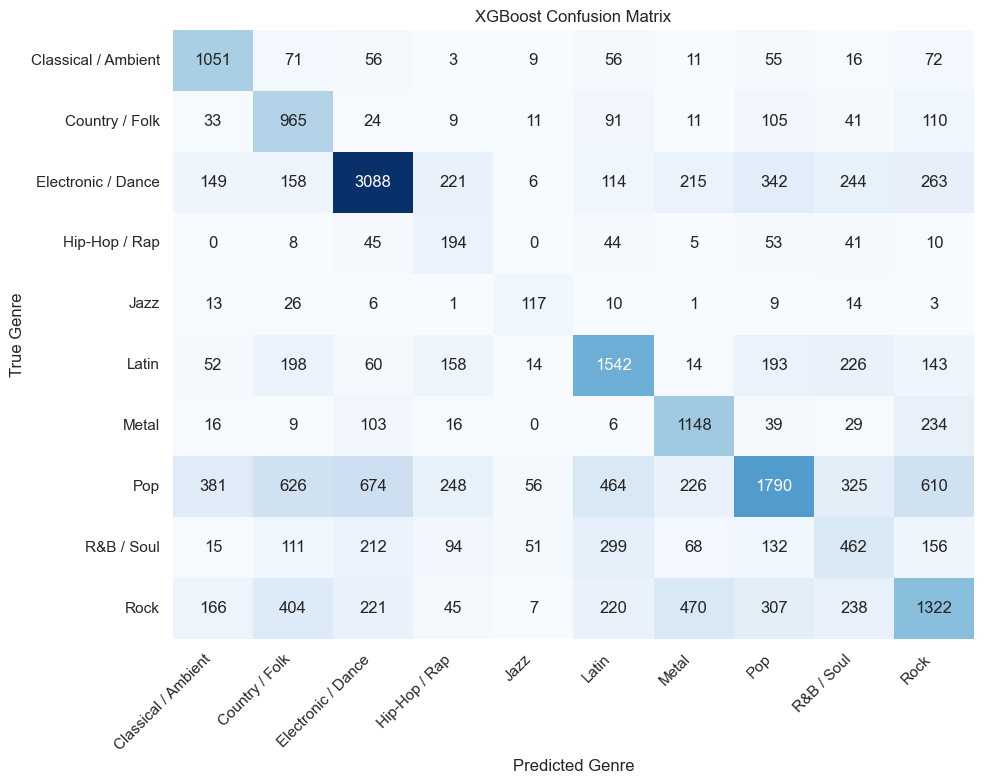

C:\Users\kkany\AppData\Local\Temp\ipykernel_12116\3463140577.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x="importance", y="feature", palette="mako")


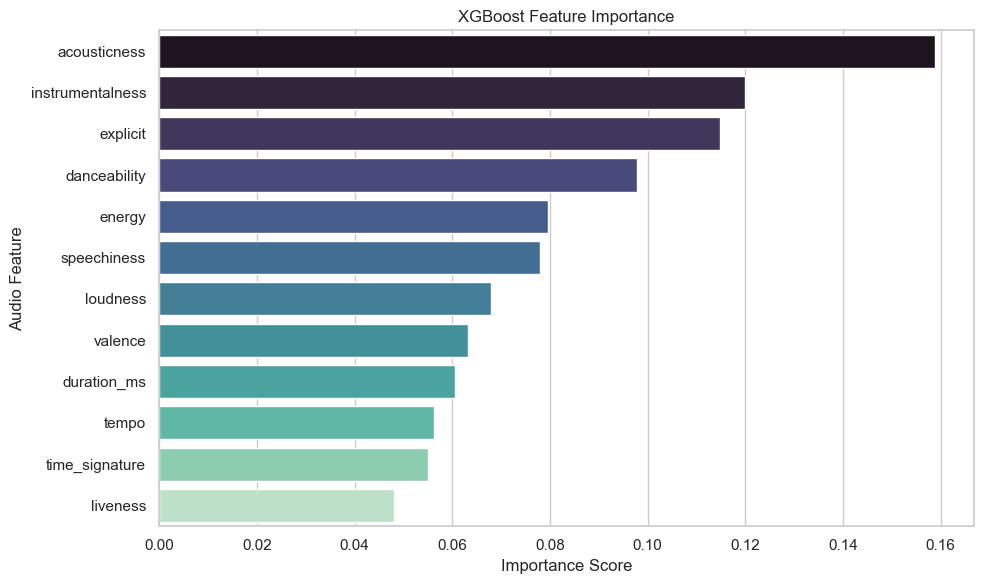

In [6]:
# STEP 6: High-Performance Pipeline and Visualizations
import json
from pathlib import Path

# Run the pipeline (without --tune for speed in the notebook, or add --tune if you want to wait)
!python high_performance_genre_pipeline.py --data spotify_remapped.csv

# Load the saved artifacts
out_dir = Path("model_outputs/high_performance_xgb")
cm_df = pd.read_csv(out_dir / "confusion_matrix.csv", index_col=0)
feat_imp = pd.read_csv(out_dir / "feature_importance.csv")

# 1. Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("XGBoost Confusion Matrix")
plt.ylabel("True Genre")
plt.xlabel("Predicted Genre")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# 2. Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(data=feat_imp, x="importance", y="feature", palette="mako")
plt.title("XGBoost Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Audio Feature")
plt.tight_layout()
plt.show()